# 🏆 Scoring Multicriterio

## ¿Por qué un scoring y no simplemente el ranking de ganancia?

El ranking de ganancia mensual responde solo una pregunta. Pero un conductor
real tiene múltiples criterios al momento de comprar un auto:

- ¿Cuánto capital tengo disponible?
- ¿Priorizo ganar más o perder menos en el peor escenario?
- ¿Me importa la resiliencia ante una devaluación?
- ¿Qué tan rápido quiero recuperar la inversión?

El **scoring multicriterio** construye un puntaje 0-100 para cada auto
combinando todas estas dimensiones con pesos configurables según el perfil
del conductor. Permite comparar autos que no son directamente comparables
con un solo número.

## Dimensiones del scoring

| Dimensión | Variable base | ¿Qué mide? |
|---|---|---|
| Rentabilidad | Ganancia P50 Montecarlo | Ganancia típica mensual |
| Resiliencia | Ganancia P10 Montecarlo | Peor escenario probable |
| Accesibilidad | Precio de compra | Qué tan fácil es entrar |
| Payback | Meses para recuperar inversión | Velocidad de retorno |
| Estabilidad | Desvío estándar Montecarlo | Predictibilidad de ingresos |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import sys
sys.path.append("..")

# Cargar resultados de Montecarlo
# (necesitamos correr la simulación de nuevo o cargar los resultados)
from src.modelo import PARAMETROS
import requests
from bs4 import BeautifulSoup

def get_tipo_cambio():
    url = "https://dolarhoy.com/"
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers, timeout=10)
    soup = BeautifulSoup(response.text, "html.parser")
    valores = soup.find_all("div", class_="val")
    venta_blue = valores[5].text.strip().replace("$","").replace(".","").replace(",",".")
    return float(venta_blue)

TIPO_CAMBIO = get_tipo_cambio()
df = pd.read_csv("../data/processed/precios_autos_procesado.csv")
precio_mediano = df.groupby("modelo")["precio_usd"].median()

np.random.seed(42)
N = 10_000
p = PARAMETROS

consumo_por_modelo = {
    "Toyota Etios":        8.5, "Toyota Corolla":      9.0,
    "Toyota Yaris":        8.0, "Chevrolet Prisma":    8.5,
    "Chevrolet Onix Plus": 7.8, "Renault Logan":       8.0,
    "Nissan Versa":        9.0, "VW Virtus":           8.5,
    "VW Voyage":           9.5, "VW Gol":              9.0,
    "Ford Ka":             8.0, "Ford Fiesta":         9.0,
    "Fiat Siena":          9.5, "Fiat Cronos":         8.4,
    "Peugeot 208":         7.5,
}

tiene_gnc = {
    "Toyota Etios": False, "Toyota Corolla": False, "Toyota Yaris": False,
    "Chevrolet Prisma": True, "Chevrolet Onix Plus": False, "Renault Logan": True,
    "Nissan Versa": False, "VW Virtus": False, "VW Voyage": True, "VW Gol": True,
    "Ford Ka": False, "Ford Fiesta": False, "Fiat Siena": True,
    "Fiat Cronos": True, "Peugeot 208": False,
}

def simular(precio_usd, consumo, gnc, n=N):
    nafta  = np.random.normal(p["precio_nafta_ars_litro"], p["precio_nafta_ars_litro"]*0.15, n)
    gncp   = np.random.normal(p["precio_gnc_ars_m3"], p["precio_gnc_ars_m3"]*0.15, n)
    km_dia = np.abs(np.random.normal(p["km_diarios"], 20, n))
    tc     = np.abs(np.random.normal(TIPO_CAMBIO, 150, n))
    ing    = np.random.triangular(600_000, 2_000_000, 2_800_000, n)

    km_mes = km_dia * p["dias_laborales_mes"]
    costo_comb = (km_mes/100)*10*gncp if gnc else (km_mes/100)*consumo*nafta
    amort = (precio_usd * tc / p["vida_util_km"]) * km_mes
    ing_neto = ing * (1 - p["comision_cabify"])
    ganancia_ars = ing_neto - costo_comb - amort - p["seguro_mensual_ars"] - p["patente_anual_ars"]/12
    return ganancia_ars / tc

resultados_mc = {}
for modelo in consumo_por_modelo:
    resultados_mc[modelo] = simular(precio_mediano[modelo], consumo_por_modelo[modelo], tiene_gnc[modelo])

print("Simulación lista ✅")

Simulación lista ✅


### Construcción del scoring

Cada dimensión se normaliza al rango 0-100 usando **min-max scaling**:

score = (valor - min) / (max - min) * 100

Esto hace que el peor auto en cada dimensión reciba 0 y el mejor reciba 100,
permitiendo comparar dimensiones que tienen unidades distintas (USD, meses, etc.).

Los pesos de cada dimensión suman 1.0 y son configurables según el perfil
del conductor.

In [2]:
def minmax(serie):
    return (serie - serie.min()) / (serie.max() - serie.min()) * 100

# Construir tabla de métricas base
metricas = pd.DataFrame({
    "p50_usd":      {m: np.percentile(resultados_mc[m], 50) for m in resultados_mc},
    "p10_usd":      {m: np.percentile(resultados_mc[m], 10) for m in resultados_mc},
    "std_usd":      {m: np.std(resultados_mc[m])            for m in resultados_mc},
    "precio_usd":   precio_mediano,
    "payback_meses":{m: precio_mediano[m]*TIPO_CAMBIO / 
                    (np.percentile(resultados_mc[m], 50)*TIPO_CAMBIO)
                    for m in resultados_mc},
    "gnc":          tiene_gnc,
})

# Normalizar — para precio y payback invertimos (menor es mejor)
metricas["score_rentabilidad"] = minmax(metricas["p50_usd"])
metricas["score_resiliencia"]  = minmax(metricas["p10_usd"])
metricas["score_accesibilidad"]= minmax(-metricas["precio_usd"])   # invertido
metricas["score_payback"]      = minmax(-metricas["payback_meses"]) # invertido
metricas["score_estabilidad"]  = minmax(-metricas["std_usd"])       # invertido

print("Métricas normalizadas:")
score_cols = [c for c in metricas.columns if c.startswith("score_")]
print(metricas[score_cols].round(1).to_string())

Métricas normalizadas:
                     score_rentabilidad  score_resiliencia  score_accesibilidad  score_payback  score_estabilidad
Chevrolet Onix Plus                25.1               24.2                 37.8           64.7               44.3
Chevrolet Prisma                   96.2               95.8                 90.8           98.3               71.8
Fiat Cronos                        79.6               79.7                 40.2           87.6               76.0
Fiat Siena                        100.0              100.0                100.0          100.0              100.0
Ford Fiesta                        28.0               26.7                 79.6           81.2               29.9
Ford Ka                            39.8               39.7                 85.8           87.8               48.7
Nissan Versa                       20.8               20.7                 57.1           68.4               46.7
Peugeot 208                        24.0               24.1       

### Perfiles de conductor

Definí tres perfiles con distintas prioridades para mostrar que el
"mejor auto" depende del contexto de cada conductor:

- **Perfil A — Maximizador:** tiene capital disponible, prioriza ganancia mensual
- **Perfil B — Conservador:** prioriza no perder plata en el peor escenario
- **Perfil C — Capital limitado:** prioriza precio de entrada bajo y payback rápido

In [3]:
perfiles = {
    "Maximizador": {
        "score_rentabilidad": 0.40,
        "score_resiliencia":  0.20,
        "score_accesibilidad":0.10,
        "score_payback":      0.20,
        "score_estabilidad":  0.10,
    },
    "Conservador": {
        "score_rentabilidad": 0.20,
        "score_resiliencia":  0.40,
        "score_accesibilidad":0.10,
        "score_payback":      0.10,
        "score_estabilidad":  0.20,
    },
    "Capital limitado": {
        "score_rentabilidad": 0.20,
        "score_resiliencia":  0.10,
        "score_accesibilidad":0.40,
        "score_payback":      0.25,
        "score_estabilidad":  0.05,
    },
}

for perfil, pesos in perfiles.items():
    metricas[f"score_{perfil}"] = sum(
        metricas[dim] * peso for dim, peso in pesos.items()
    )

# Mostrar ranking por perfil
print("=== RANKING POR PERFIL ===\n")
for perfil in perfiles:
    col = f"score_{perfil}"
    ranking = metricas[col].sort_values(ascending=False)
    print(f"Perfil {perfil}:")
    for i, (modelo, score) in enumerate(ranking.items(), 1):
        gnc_tag = "🟢" if tiene_gnc[modelo] else "🔵"
        print(f"  {i:2}. {gnc_tag} {modelo:<20} {score:.1f}/100")
    print()

=== RANKING POR PERFIL ===

Perfil Maximizador:
   1. 🟢 Fiat Siena           100.0/100
   2. 🟢 VW Voyage            97.0/100
   3. 🟢 Chevrolet Prisma     93.5/100
   4. 🟢 VW Gol               92.1/100
   5. 🟢 Renault Logan        90.8/100
   6. 🟢 Fiat Cronos          76.9/100
   7. 🔵 Ford Ka              54.9/100
   8. 🔵 Ford Fiesta          43.7/100
   9. 🔵 Toyota Etios         41.2/100
  10. 🔵 Nissan Versa         36.5/100
  11. 🔵 Chevrolet Onix Plus  36.0/100
  12. 🔵 VW Virtus            34.7/100
  13. 🔵 Peugeot 208          33.1/100
  14. 🔵 Toyota Yaris         22.3/100
  15. 🔵 Toyota Corolla       0.0/100

Perfil Conservador:
   1. 🟢 Fiat Siena           100.0/100
   2. 🟢 VW Voyage            97.0/100
   3. 🟢 VW Gol               92.1/100
   4. 🟢 Chevrolet Prisma     90.8/100
   5. 🟢 Renault Logan        89.7/100
   6. 🟢 Fiat Cronos          75.8/100
   7. 🔵 Ford Ka              51.0/100
   8. 🔵 Ford Fiesta          38.3/100
   9. 🔵 Toyota Etios         37.4/100
  10. 🔵 Nissan Ver

### Visualización del scoring por perfil

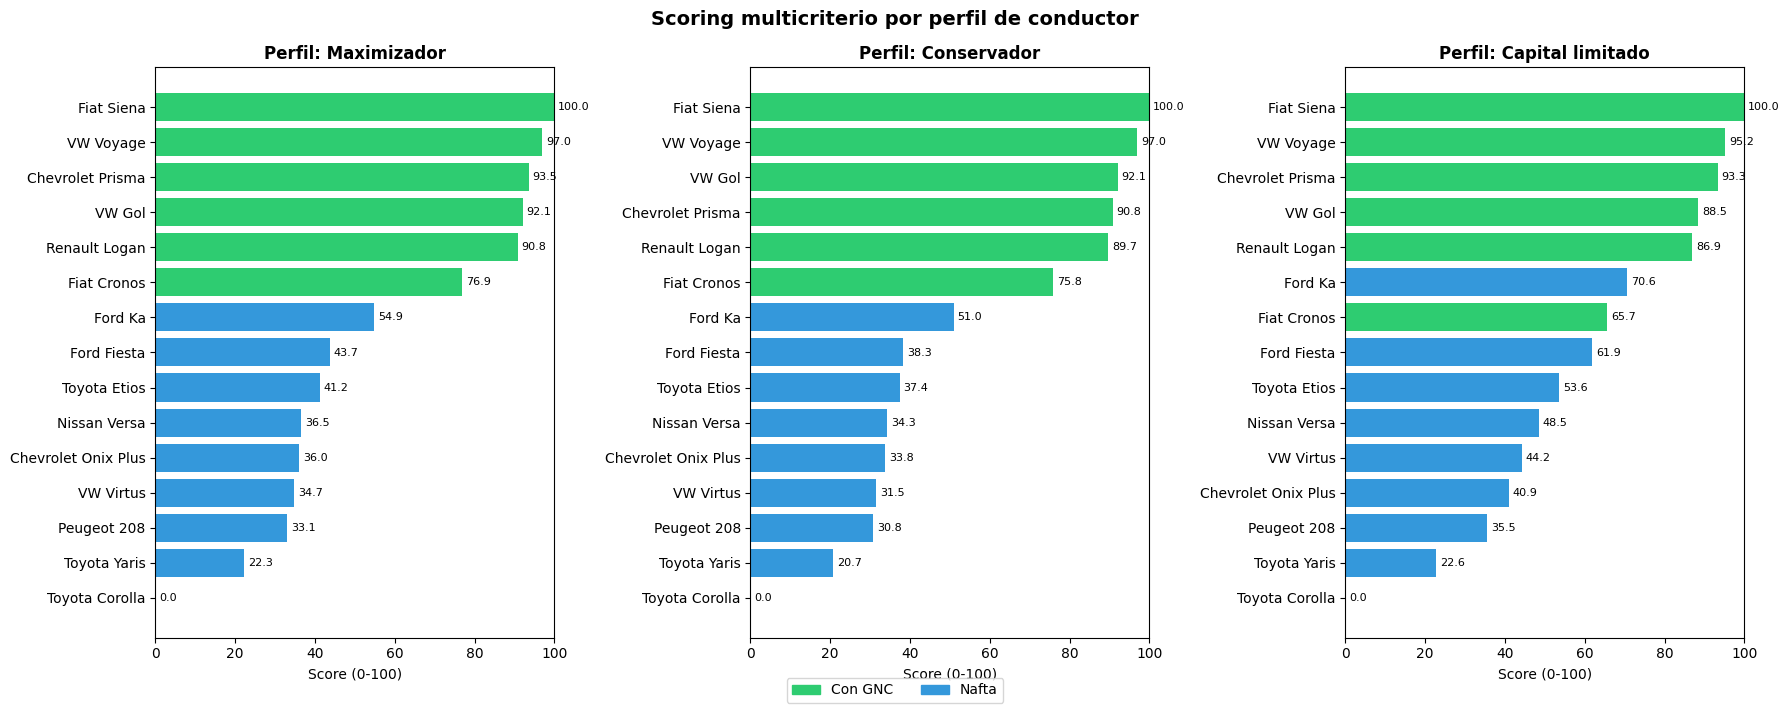

Gráfico guardado.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("Scoring multicriterio por perfil de conductor", fontsize=14, fontweight="bold")

for ax, perfil in zip(axes, perfiles):
    col = f"score_{perfil}"
    df_plot = metricas[col].sort_values(ascending=True)
    colores = ["#2ecc71" if tiene_gnc[m] else "#3498db" for m in df_plot.index]

    ax.barh(df_plot.index, df_plot.values, color=colores)
    ax.set_title(f"Perfil: {perfil}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Score (0-100)")
    ax.set_xlim(0, 100)
    for i, v in enumerate(df_plot.values):
        ax.text(v + 1, i, f"{v:.1f}", va="center", fontsize=8)

patch_gnc   = mpatches.Patch(color="#2ecc71", label="Con GNC")
patch_nafta = mpatches.Patch(color="#3498db", label="Nafta")
fig.legend(handles=[patch_gnc, patch_nafta], loc="lower center",
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig("../reports/figures/05_scoring_perfiles.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado.")

### Interpretación del scoring multicriterio

Los tres perfiles confirman que el **Fiat Siena domina en cualquier contexto**,
obteniendo el primer puesto con 100/100 en los tres perfiles: es a la vez el más
barato, el más rentable, el más resiliente y el más estable del análisis.
Sin embargo, hay matices importantes en los puestos siguientes:

**Perfil Maximizador:** el top 6 está compuesto íntegramente por autos con GNC
(Siena, Voyage, Prisma, Gol, Logan y Cronos). La rentabilidad mensual es tan
superior en estos modelos que ningún auto a nafta puede competir con ellos
cuando el objetivo es maximizar ganancias.

**Perfil Conservador:** el ranking casi no cambia respecto al Maximizador, pero
por una razón distinta. Los autos con GNC no solo ganan más — generan ganancias
más **predecibles y estables**, con probabilidad de mes positivo superior al 98%,
mientras que los autos a nafta tienen P10 negativo (pueden perder plata en un mes
malo). Un conductor conservador valora esa certeza tanto como la ganancia media.
El VW Gol sube al 3° puesto por su alta estabilidad.

**Perfil Capital limitado:** es el perfil donde el ranking cambia más. El
**Ford Ka sube al puesto 6**, desplazando al Fiat Cronos — que a pesar del GNC
tiene un precio de entrada alto ($17.000 USD, unidades casi 0km). Para un
conductor con presupuesto acotado, un auto barato a nafta puede competir con
los GNC caros porque el bajo precio de entrada genera un payback rápido.
Esto demuestra que **el GNC no compensa cualquier precio de compra**.

**Conclusión general:** la decisión de qué auto comprar no tiene una respuesta
única — depende del perfil del conductor. Sin embargo, el Fiat Siena con GNC es
robusto ante cualquier perfil: es el más barato del análisis, tiene GNC y
recupera la inversión en ~11 meses.

---

## 🏁 Conclusiones generales del análisis

Este proyecto analizó 3.780 publicaciones reales de MercadoLibre (2.440 elegibles
tras el filtro regulatorio de antigüedad y la limpieza de outliers) para determinar
qué auto es más rentable para trabajar en Cabify en AMBA. A lo largo de 5 fases
de análisis llegué a las siguientes conclusiones:

### Hallazgos principales

1. **El Fiat Siena con GNC es el auto más rentable en cualquier perfil de
   conductor.** Con una ganancia neta de ~$782 USD/mes (modelo determinístico) y
   un payback de ~11 meses, domina el ranking porque combina el precio de entrada
   más bajo del análisis ($8.653 USD) con el combustible más barato.

2. **El GNC es el factor diferenciador más importante.** Con el precio actual de
   la nafta, los autos a GNC gastan ~$195.000 ARS/mes en combustible contra
   $595.000-$714.000 de los de nafta — un ahorro de ~$400.000-$500.000 ARS/mes.
   Los 6 primeros puestos del ranking son todos autos con GNC.

3. **El precio de compra es el segundo factor clave.** Dentro de los autos con
   GNC, el más barato gana — no porque consuma menos sino porque amortiza menos
   por mes. El Fiat Siena, VW Voyage y Chevrolet Prisma tienen costos de
   combustible idénticos; lo que los separa es el precio de entrada.

4. **La simulación de Montecarlo reveló que el ingreso bruto mensual es la
   variable con mayor impacto en la rentabilidad (±$246 USD ante una variación
   del 20%)**, por encima del tipo de cambio (-$158/+$236 USD) y del precio del
   combustible (±$28 USD para un auto con GNC). Esto significa que el conductor
   tiene más poder sobre su rentabilidad optimizando sus horas de trabajo que
   preocupándose por los costos del auto.

5. **El filtro regulatorio (año ≥ 2016) cambió el ranking.** El VW Gol, líder
   del análisis pre-filtro, cayó al 4°-5° puesto: su bajo precio mediano estaba
   explicado por unidades viejas no elegibles para Cabify (quedaron solo 12
   publicaciones válidas). El Fiat Cronos, reincorporado al análisis, entra 6°
   gracias al GNC a pesar de su precio alto.

6. **El Toyota Corolla es el auto menos rentable del análisis.** A pesar de
   ser el más cómodo y confiable, su precio de entrada (~$22.600 USD) genera
   una amortización mensual tan alta que lo deja último en el ranking con
   ~$255 USD/mes de ganancia neta, ~89 meses de payback y solo 69% de
   probabilidad de ganancia positiva en la simulación.

### Limitaciones del análisis

- Los precios de compra son medianas del mercado de **usados** en MercadoLibre. Un auto más nuevo o más caro que el mediano va a tener menor
  rentabilidad que la estimada.
- Los ingresos brutos están basados en un relevamiento de 25+ choferes activos
  en AMBA. Pueden variar significativamente según zona, horario y temporada.
- El modelo no incluye costos de reparaciones no planificadas ni días perdidos
  por falla mecánica — variables difíciles de estimar sin datos históricos.
- El análisis es válido para AMBA. En el interior del país los precios de
  combustible, seguros y autos usados pueden diferir significativamente.
- El Fiat Siena elegible es mayormente año 2016 con ~124.500 km — la unidad más
  vieja permitida. Quien lo compre debería considerar que en pocos años quedará
  fuera del límite regulatorio de antigüedad.

### Próximos pasos posibles
- Incorporar datos de confiabilidad mecánica por modelo (JD Power, foros)
- Modelar el impacto de días perdidos por rotura en la rentabilidad anual
- Expandir el análisis a otras ciudades (Córdoba, Rosario)
- Actualizar el dataset periódicamente para seguir la evolución de precios